In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 
import sys

from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

In [2]:
# set device to cuda if available 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# set float type to torch.float to save memory
float_type = { 
    "device" : device, 
    "dtype" : torch.float, 
}

cpu


In [3]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file="/gpfs/commons/groups/knowles_lab/data/sc/pbmc/Leaflet/PBMC1_PBMC2_intron_clusters_model_input.h5"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=10000, remove_singletons=True, has_genes="yes")

# Note: the input to load_cluster_data may be either a single file (input_file=X) or a folder of files (input_folder=X) as indicated above. 
print(cell_ids_conversion.head())

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  24199
Number of junctions after removing singletons:  24199
The number of unique cell types in the data is:  747
The number of unique cells in the data is:  747
The number of unique junctions in the data is:  24200
The maximum junction count was initially:  12842
2
The maximum junction count is now:  4906
The number of junctions in the data is:  24168
The number of cells in the data is:  747
The number of cell types in the data is:  747
      cell_id_index                                            cell_id  \
0                 0  ?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...   
1196              1  ?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...   
1198              2  ?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...   
1683              3  ?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...   
2093              4  ?_/gpfs/commons/groups

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [4]:
simple_data_human = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

In [5]:
print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))

The number of junctions is:  24168
The number of intron clusters observed is:  8363
The number of genes is:  6032


In [7]:
cell_types = simple_data_human["cell_type"].unique()
# turn into dataframe 
cell_types = pd.DataFrame(cell_types, columns=["cell_type"])
# split cell_type column
cell_types = cell_types["cell_type"].str.split("/", expand=True)
# keep only the last column
cell_types = cell_types[[9,10]]
# rename columns to be "donor" and "sample_ID"
cell_types.columns = ["donor", "sample_ID"]
cell_types["cell_type_clean"] = cell_types.apply(lambda x: "_".join(x), axis=1)
cell_types["cell_type"] = simple_data_human["cell_type"].unique()

In [8]:
simple_data_human = simple_data_human.merge(cell_types, on="cell_type")
# remove cell_type column and rename cell_type_clean as cell_type
simple_data_human = simple_data_human.drop(columns=["cell_type"])
simple_data_human = simple_data_human.rename(columns={"cell_type_clean": "cell_type"})

In [9]:
# add cell_type to cell_ids_conversion
cell_ids_conversion = cell_ids_conversion.merge(cell_types, on="cell_type", how="left")
# do the same remove old cell_type column and rename cell_type_clean
cell_ids_conversion = cell_ids_conversion.drop(columns=["cell_type"])
cell_ids_conversion = cell_ids_conversion.rename(columns={"cell_type_clean": "cell_type"})
cell_ids_conversion

,cell_id_index,cell_id,donor,sample_ID,cell_type
0,0,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC1,SRR9167510,PBMC1_SRR9167510
1,1,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC1,SRR9167511,PBMC1_SRR9167511
2,2,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC1,SRR9167512,PBMC1_SRR9167512
3,3,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC1,SRR9167513,PBMC1_SRR9167513
4,4,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC1,SRR9167514,PBMC1_SRR9167514
...,...,...,...,...,...
742,742,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2,SRR9171297,PBMC2_SRR9171297
743,743,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2,SRR9171298,PBMC2_SRR9171298
744,744,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2,SRR9171300,PBMC2_SRR9171300
745,745,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2,SRR9171301,PBMC2_SRR9171301


In [10]:
torch.manual_seed(42)
np.random.seed(42)

# Let's try to first set K to 10 
K = 2

# Define model priors
hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., 
    "pi_prior" : 1.
}

print(hypers["eta"])

0.5


In [11]:
num_trials = 2 # let's run the model 10 times with different initializations
num_iters = 100 # max number of iterations for CAVI 
print("The K used is: ", K)
results = [calculate_CAVI(K, my_data, float_type, hypers, num_iterations = num_iters) 
           for t in range(num_trials) ]

The K used is:  2
Initialize VI params
Initializing variational parameters with N = 747 cells and J = 24168 junctions
Running CAVI with unknown cell types (not predefined)
z and theta will be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
Updating z and thetaI iteration #  1
Updating z and theta iteration #  2
Updating z and theta iteration #  3
Updating z and theta iteration #  4
Updating z and theta iteration #  5
Updating z and theta iteration #  6
Updating z and theta iteration #  7
Updating z and theta iteration #  8
Updating z and theta iteration #  9
Updating z and theta iteration #  10
Updating z and theta iteration #  11
ELBO converged @ -8063320.5 CAVI iteration # 11 complete
ELBO converged @ -8063320.5 CAVI iteration # 11 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 747 cells and J = 24168 junctions
Running CAVI with unknown cell types (not predefined)
z and theta will be updated!
Got the initial ELBO ^
The toleran

The trial with the highest ELBO was 0


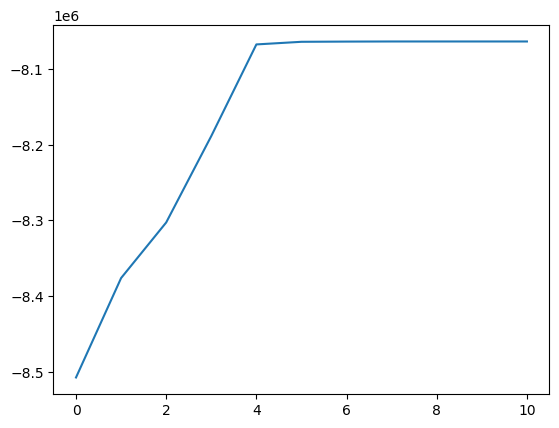

In [12]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

In [13]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()

(array([726.,   3.,   4.,   1.,   1.,   4.,   1.,   2.,   0.,   3.,   0.,
          2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.,   0.,   3.,   0.,   2.,   1.,   4.,   1.,   1.,   4.,   3.,
        726.]),
 array([0.        , 0.01      , 0.02      , 0.03      , 0.04      ,
        0.05      , 0.06      , 0.07      , 0.08      , 0.09      ,
        0.1       , 0.11      , 0.12      , 0.13      , 0.14      ,
        0.15000001, 0.16      , 0.17      , 0.18000001, 0.19      ,
        0.2       , 0.20999999, 0.22      , 0.

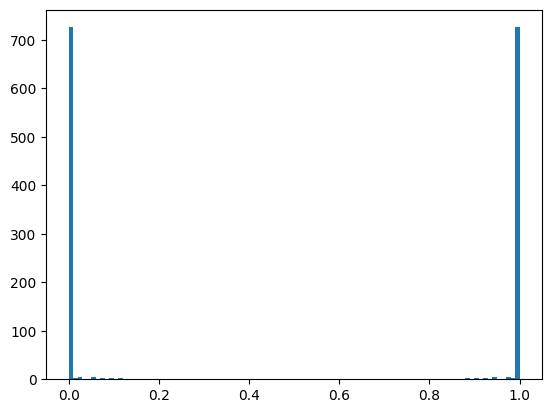

In [14]:
np.array(PHI_f.flatten())
# make histogram of the cell type proportions
plt.hist(np.array(PHI_f.flatten()), bins=100)

In [15]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 
print(percentages)

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

# rename cell_state to be from 0 to K-1 based on order in sorted_cell_states
GAMMA_f_plot

tensor([0.9416, 0.0584])


,theta,cell_state,new_cell_state
0,0.941627,0,0
1,0.058373,1,1


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/scratch/ipykernel_31974/1628281085.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


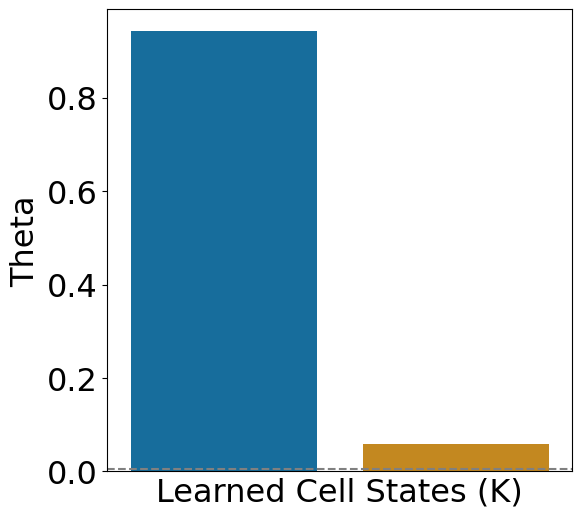

In [16]:
GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

# Make barplot using sns
plt.figure(figsize=(6, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
plt.axhline(0.005, ls='--', color='grey')

# Make Y label say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=23)
plt.xlabel("Learned Cell States (K)", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)
plt.show()

In [17]:
cell_types_summary=cell_ids_conversion['cell_type'].value_counts()
cell_types_summary=pd.DataFrame(cell_types_summary)
cell_types_summary.reset_index(inplace=True)
cell_types_summary.columns=['cell_type','count']

# get percentage of each cell type in the data 
cell_types_summary['percentage']=cell_types_summary['count']/cell_types_summary['count'].sum()
cell_types_summary.sort_values(by='percentage',ascending=False,inplace=True)
print(cell_types_summary)

            cell_type  count  percentage
0    PBMC1_SRR9167510      1    0.001339
501  PBMC1_SRR9167519      1    0.001339
492  PBMC1_SRR9167751      1    0.001339
493  PBMC1_SRR9167531      1    0.001339
494  PBMC1_SRR9167512      1    0.001339
..                ...    ...         ...
251  PBMC2_SRR9171296      1    0.001339
252  PBMC2_SRR9171297      1    0.001339
253  PBMC2_SRR9171298      1    0.001339
254  PBMC2_SRR9171300      1    0.001339
746  PBMC2_SRR9171302      1    0.001339

[747 rows x 3 columns]


In [19]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Keep only cell states defined above GAMMA_f_plot.index.values
PHI_f = PHI_f.loc[:, GAMMA_f_plot.index.values]
PHI_f

,0,1
0,1.000000,0.000000
1,0.994332,0.005668
2,1.000000,0.000000
3,1.000000,0.000000
4,1.000000,0.000000
...,...,...
742,1.000000,0.000000
743,1.000000,0.000000
744,1.000000,0.000000
745,1.000000,0.000000


In [20]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i+1) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values

In [21]:
PHI_f_melt = pd.melt(PHI_f, id_vars=['cell_id', 'cell_type'], value_vars=PHI_f.columns[:-2])

# for each cell, choose cell state with highest probability
PHI_f_melt = PHI_f_melt.sort_values(by=['cell_id', 'value'], ascending=False).drop_duplicates(subset=['cell_id'])
PHI_f_melt.head()

,cell_id,cell_type,variable,value
746,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2_SRR9171302,CellState_1,1.0
745,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2_SRR9171301,CellState_1,1.0
744,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2_SRR9171300,CellState_1,1.0
743,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2_SRR9171298,CellState_1,1.0
742,?_/gpfs/commons/groups/knowles_lab/data/sc/pbm...,PBMC2_SRR9171297,CellState_1,1.0


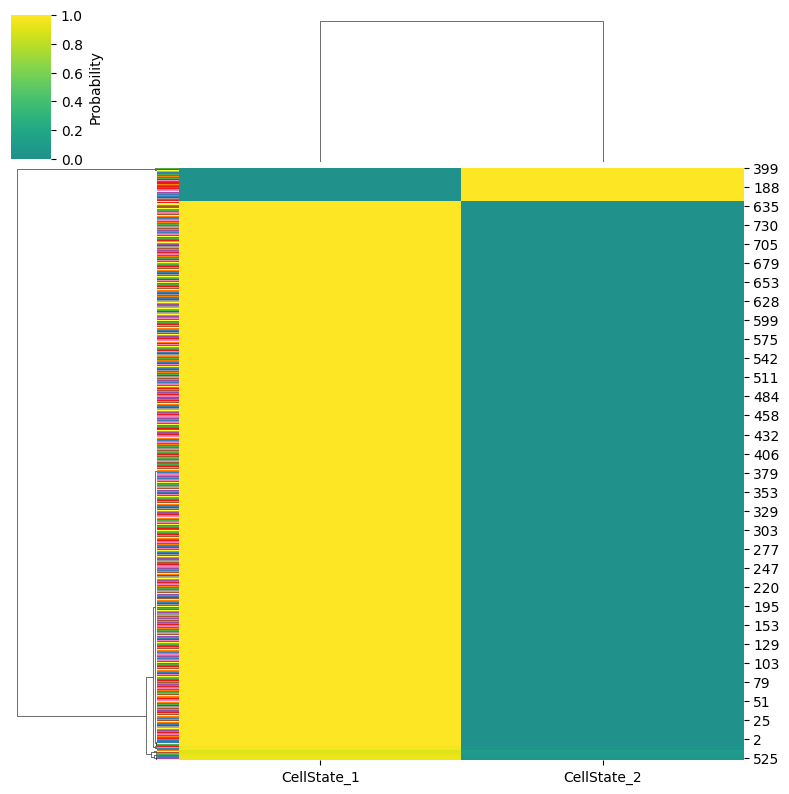

In [22]:
# add cell type colorbar to sns.clustermap of PHI_f
cell_types = PHI_f['cell_type']
unique_cell_types = cell_types.unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = dict(zip(unique_cell_types, colors))

sns.clustermap(PHI_f.iloc[:, :-2], cmap="viridis", figsize=(8, 8), center=0, cbar_kws={'label': 'Probability'}, row_colors=[cell_type_colors[cell_type] for cell_type in cell_types])

In [ ]:
# show which colour was used for each cell_type
for cell_type, color in cell_type_colors.items():
    plt.plot([], [], 'o', label=cell_type, color=color, markersize=27, linestyle='None')  # Use 'o' to show the colors clearly
plt.legend(fontsize=20)
plt.axis('off')  # Turn off axis
plt.show()